C:\Users\won20\AppData\Local\Temp\ipykernel_19452\117972086.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2015-01-01', end='2022-12-31')
[*********************100%***********************]  1 of 1 completed
c:\Users\won20\anaconda3\envs\2ndpjt\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0372 - val_loss: 5.5063e-04
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0036 - val_loss: 5.0473e-04
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0017 - val_loss: 9.3772e-04
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0014 - val_loss: 7.3319e-04
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0012 - val_loss: 5.5938e-04
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0010 - val_loss: 7.4188e-04
Epoch 7/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 8.6221e-04 - val_loss: 0.0018
Epoch 8/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 6.8860e-04 - val_loss: 3.5737e-04
Epoch 9/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 6.4638e-04 - val_loss: 9.2039e-04
Epoch 10/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 5.9649e-04 - val_loss: 5.4409e-04
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Test RMSE: 0.0353


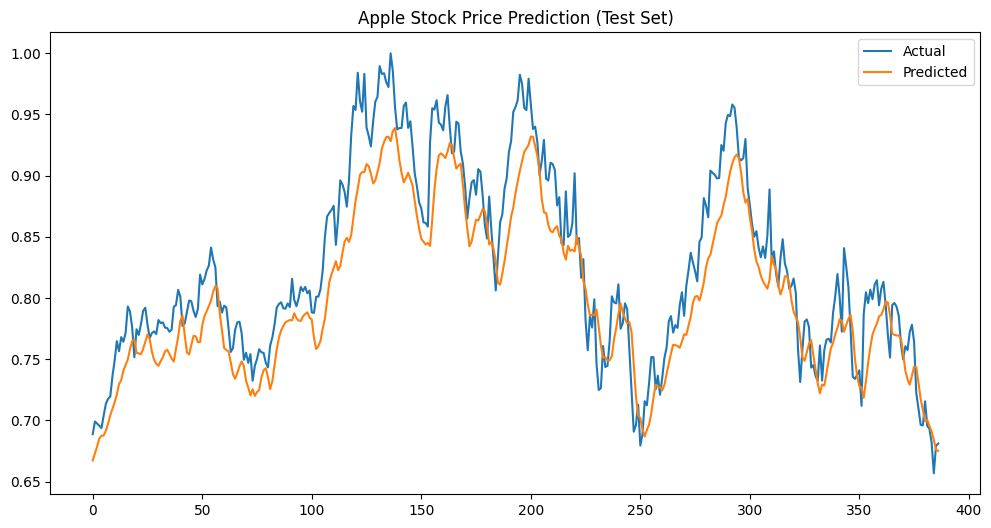

In [1]:

# Apple 주가 예측: LSTM 실험
# 작성자: ChatGPT
# 대상: Apple (AAPL), 일간 데이터, 2015~2022

## 1. 라이브러리 불러오기
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from sklearn.metrics import mean_squared_error
import math

## 2. 데이터 다운로드
ticker = 'AAPL'
df = yf.download(ticker, start='2015-01-01', end='2022-12-31')
df = df[['Open', 'High', 'Low', 'Close', 'Volume']]

## 3. 기술적 지표 추가
def add_technical_indicators(df):
    df['SMA20'] = df['Close'].rolling(window=20).mean()
    df['EMA20'] = df['Close'].ewm(span=20, adjust=False).mean()
    delta = df['Close'].diff()
    up = delta.clip(lower=0)
    down = -1 * delta.clip(upper=0)
    avg_gain = up.rolling(window=14).mean()
    avg_loss = down.rolling(window=14).mean()
    rs = avg_gain / avg_loss
    df['RSI'] = 100 - (100 / (1 + rs))
    ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = ema_12 - ema_26
    df['BB_upper'] = df['Close'].rolling(window=20).mean() + 2 * df['Close'].rolling(window=20).std()
    df['BB_lower'] = df['Close'].rolling(window=20).mean() - 2 * df['Close'].rolling(window=20).std()
    low_14 = df['Low'].rolling(window=14).min()
    high_14 = df['High'].rolling(window=14).max()
    df['%K'] = 100 * ((df['Close'] - low_14) / (high_14 - low_14))
    df['%D'] = df['%K'].rolling(window=3).mean()
    return df

df = add_technical_indicators(df)
df.dropna(inplace=True)

## 4. 정규화
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

## 5. 윈도우 데이터 생성
def create_dataset(data, window_size=60):
    x, y = [], []
    for i in range(window_size, len(data)):
        x.append(data[i-window_size:i])
        y.append(data[i, 3])  # 'Close'가 4번째 컬럼
    return np.array(x), np.array(y)

x, y = create_dataset(scaled_data, 60)

## 6. 학습/테스트 분리
split = int(len(x) * 0.8)
x_train, x_test = x[:split], x[split:]
y_train, y_test = y[:split], y[split:]

## 7. 모델 정의 및 학습
model = Sequential([
    LSTM(50, return_sequences=False, input_shape=(x_train.shape[1], x_train.shape[2])),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

## 8. 예측 및 평가
predicted = model.predict(x_test)
rmse = math.sqrt(mean_squared_error(y_test, predicted))
print("Test RMSE:", round(rmse, 4))

## 9. 결과 시각화
plt.figure(figsize=(12,6))
plt.plot(y_test, label='Actual')
plt.plot(predicted, label='Predicted')
plt.legend()
plt.title('Apple Stock Price Prediction (Test Set)')
plt.show()


In [2]:
# 정규화 해제 후 실제 RMSE (단위: 달러) 계산
min_close = scaler.data_min_[3]  # 'Close' 열의 최소값
max_close = scaler.data_max_[3]  # 'Close' 열의 최대값
scale_close = max_close - min_close

# 정규화 해제
predicted_prices = predicted * scale_close + min_close
actual_prices = y_test * scale_close + min_close

# RMSE 계산 (실제 가격 기준)
from sklearn.metrics import mean_squared_error
import math

real_rmse = math.sqrt(mean_squared_error(actual_prices, predicted_prices))
print("실제 스케일 기준 Test RMSE (단위: 달러):", round(real_rmse, 2))


실제 스케일 기준 Test RMSE (단위: 달러): 5.58


C:\Users\won20\AppData\Local\Temp\ipykernel_19452\3549306615.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2015-01-01', end='2022-12-31')
[*********************100%***********************]  1 of 1 completed

Epoch 1/10



c:\Users\won20\anaconda3\envs\2ndpjt\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5280 - loss: 0.6909 - val_accuracy: 0.4968 - val_loss: 0.7062
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5099 - loss: 0.6927 - val_accuracy: 0.4968 - val_loss: 0.7061
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5412 - loss: 0.6873 - val_accuracy: 0.4968 - val_loss: 0.7064
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5181 - loss: 0.6934 - val_accuracy: 0.4968 - val_loss: 0.6966
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5465 - loss: 0.6893 - val_accuracy: 0.5032 - val_loss: 0.6942
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5290 - loss: 0.6902 - val_accuracy: 0.4968 - val_loss: 0.7040
Epoch 7/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5129 - loss: 0.6931 - val_accuracy: 0.4968 - val_loss: 0.7026
Epoch 8/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5484 - loss: 0.6883 - val_accuracy: 0.4968 - val_loss: 0.

c:\Users\won20\anaconda3\envs\2ndpjt\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\won20\anaconda3\envs\2ndpjt\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\won20\anaconda3\envs\2ndpjt\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\won20\anaconda3\envs\2ndpjt\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49849 (\N{HANGUL SYLLABLE SEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\won20\anaconda3\envs\2ndpjt\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missin

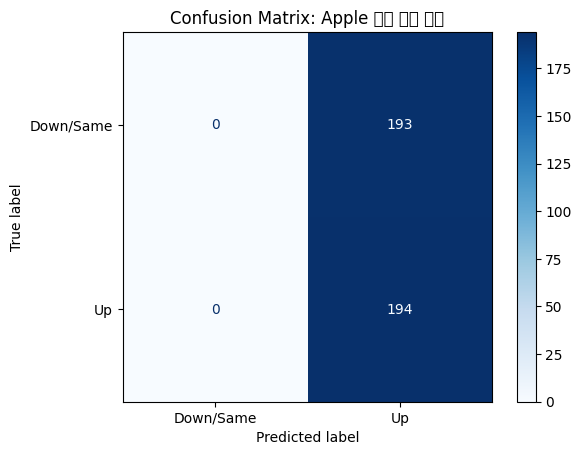

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       193
           1       0.50      1.00      0.67       194

    accuracy                           0.50       387
   macro avg       0.25      0.50      0.33       387
weighted avg       0.25      0.50      0.33       387



c:\Users\won20\anaconda3\envs\2ndpjt\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\won20\anaconda3\envs\2ndpjt\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\won20\anaconda3\envs\2ndpjt\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

In [3]:

# Apple 주가 상승 여부 예측 (이진 분류)
# 작성자: ChatGPT
# 목적: 내일 종가가 오늘보다 상승했는지 분류 (0: 하락 or 동일, 1: 상승)

## 1. 라이브러리 불러오기
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam

## 2. 데이터 다운로드
ticker = 'AAPL'
df = yf.download(ticker, start='2015-01-01', end='2022-12-31')
df = df[['Open', 'High', 'Low', 'Close', 'Volume']]

## 3. 기술적 지표 추가
def add_technical_indicators(df):
    df['SMA20'] = df['Close'].rolling(window=20).mean()
    df['EMA20'] = df['Close'].ewm(span=20, adjust=False).mean()
    delta = df['Close'].diff()
    up = delta.clip(lower=0)
    down = -1 * delta.clip(upper=0)
    avg_gain = up.rolling(window=14).mean()
    avg_loss = down.rolling(window=14).mean()
    rs = avg_gain / avg_loss
    df['RSI'] = 100 - (100 / (1 + rs))
    ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = ema_12 - ema_26
    df['BB_upper'] = df['Close'].rolling(window=20).mean() + 2 * df['Close'].rolling(window=20).std()
    df['BB_lower'] = df['Close'].rolling(window=20).mean() - 2 * df['Close'].rolling(window=20).std()
    low_14 = df['Low'].rolling(window=14).min()
    high_14 = df['High'].rolling(window=14).max()
    df['%K'] = 100 * ((df['Close'] - low_14) / (high_14 - low_14))
    df['%D'] = df['%K'].rolling(window=3).mean()
    return df

df = add_technical_indicators(df)
df.dropna(inplace=True)

## 4. 상승 여부 라벨 생성
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)
df.dropna(inplace=True)

## 5. 정규화
scaler = MinMaxScaler()
feature_cols = [col for col in df.columns if col not in ['Target']]
scaled_data = scaler.fit_transform(df[feature_cols])
labels = df['Target'].values

## 6. 윈도우 데이터 생성
def create_dataset(data, labels, window_size=60):
    x, y = [], []
    for i in range(window_size, len(data)):
        x.append(data[i-window_size:i])
        y.append(labels[i])
    return np.array(x), np.array(y)

x, y = create_dataset(scaled_data, labels)

## 7. 학습/테스트 분리
split = int(len(x) * 0.8)
x_train, x_test = x[:split], x[split:]
y_train, y_test = y[:split], y[split:]

## 8. 모델 정의 및 학습
model = Sequential([
    LSTM(50, input_shape=(x_train.shape[1], x_train.shape[2])),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

## 9. 예측 및 혼동 행렬
y_pred_prob = model.predict(x_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# 혼동 행렬 출력
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down/Same', 'Up'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix: Apple 주가 상승 예측")
plt.show()

# 상세 분류 리포트
print(classification_report(y_test, y_pred))
